<a href="https://colab.research.google.com/github/Khanbir/Agro-meteorologist-/blob/main/%D0%9C%D0%B5%D1%82%D0%B5%D0%BE_%D0%B0%D0%BD%D0%B0%D0%BB%D1%96%D0%B7_%D0%BF%D0%BE_%D0%9A%D1%80_%D0%A0%D0%BE%D0%B7%D1%96.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%pip install --upgrade meteostat pandas matplotlib

In [ ]:
import sys
import meteostat as ms
import pandas as pd
import matplotlib

print("Python:", sys.version)
print("Meteostat:", ms.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib:", matplotlib.__version__)

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Meteostat: 2.1.4
Pandas: 3.0.3
Matplotlib: 3.11.1


АГРОМЕТЕОРОЛОГІЧНИЙ АНАЛІЗ METEOSTAT
Python: 3.12.13
Meteostat: 2.1.4
Pandas: 3.0.3
Станція: 33791 — Кривий Ріг / район Новомалинівки
Період: 01.01.2014 – 31.12.2025

Завантаження даних Meteostat...
Отримано рядків: 4 383
Фактичний діапазон: 01.01.2014 – 31.12.2025

Доступні стовпці:
['temp', 'tmin', 'tmax', 'rhum', 'prcp', 'snwd', 'wspd', 'wpgt', 'pres', 'tsun', 'cldc']

Колонку "temp" використано як "tavg" для сумісності аналізу.

Щоденні дані збережено:
/content/meteostat_results/weather_daily_33791_2014-01-01_2025-12-31.csv
Місячні результати збережено:
/content/meteostat_results/weather_monthly_33791_2014-01-01_2025-12-31.csv
Річні результати збережено:
/content/meteostat_results/weather_yearly_33791_2014-01-01_2025-12-31.csv
Багаторічні середні збережено:
/content/meteostat_results/weather_climate_monthly_33791_2014-01-01_2025-12-31.csv

Формування PDF-звіту...


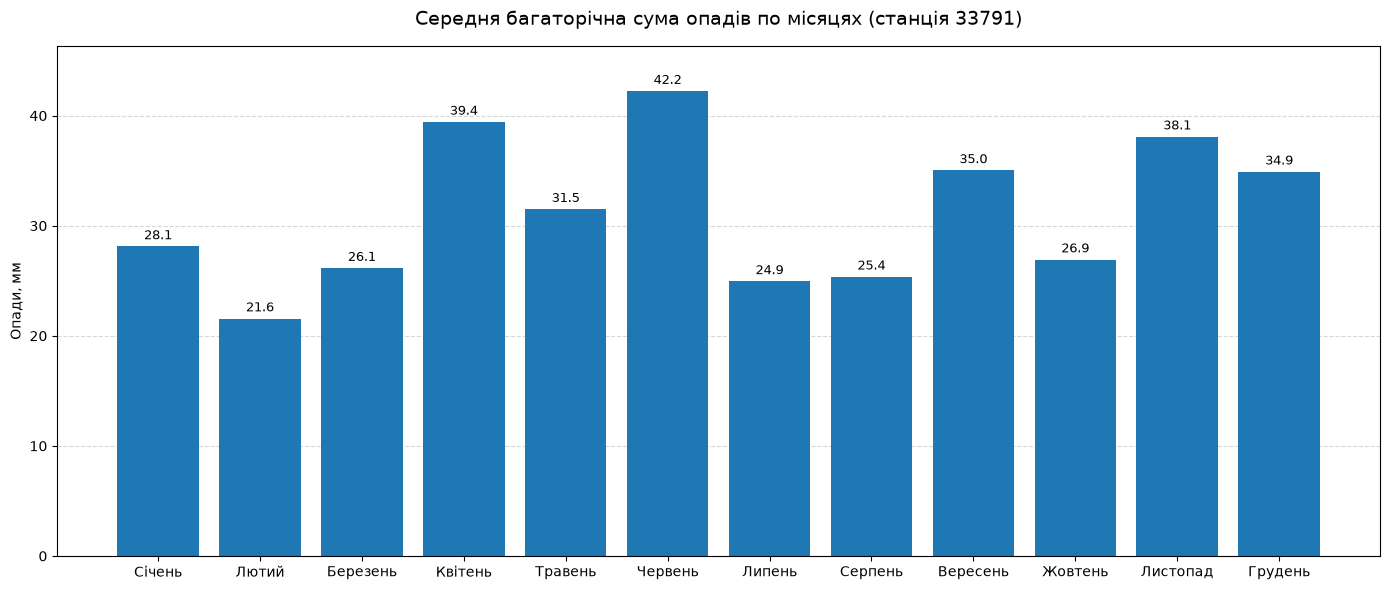

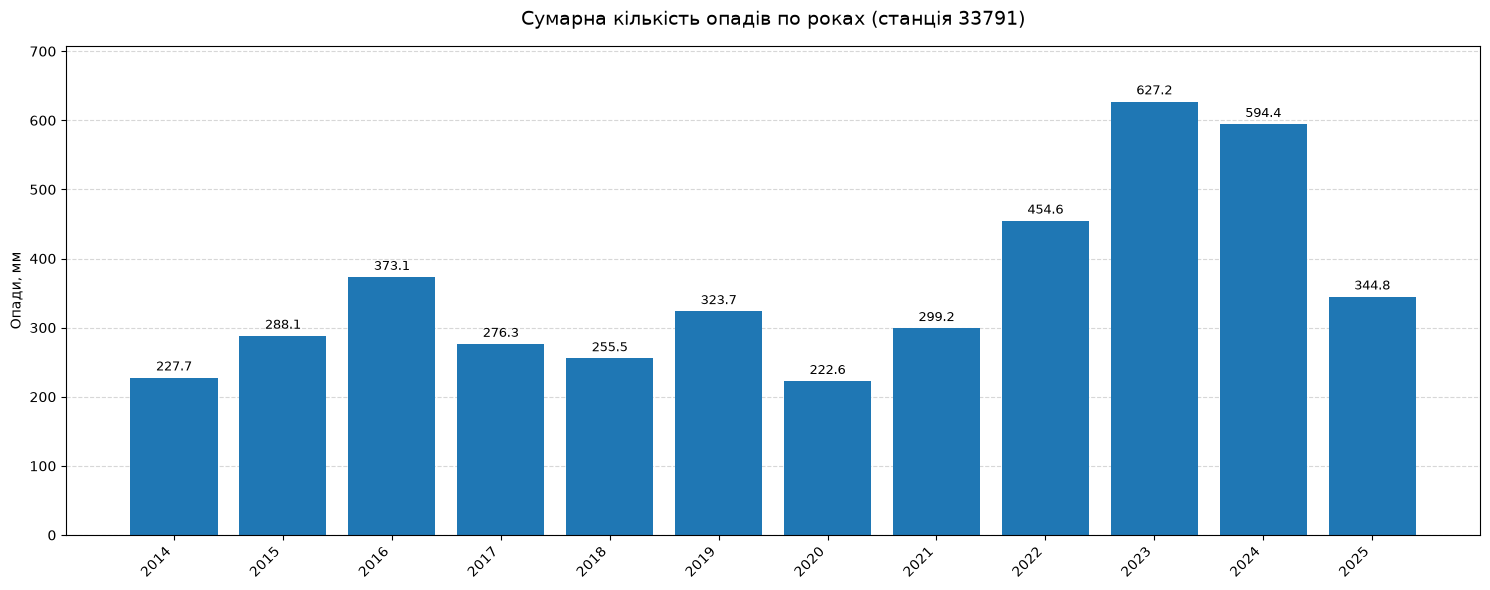

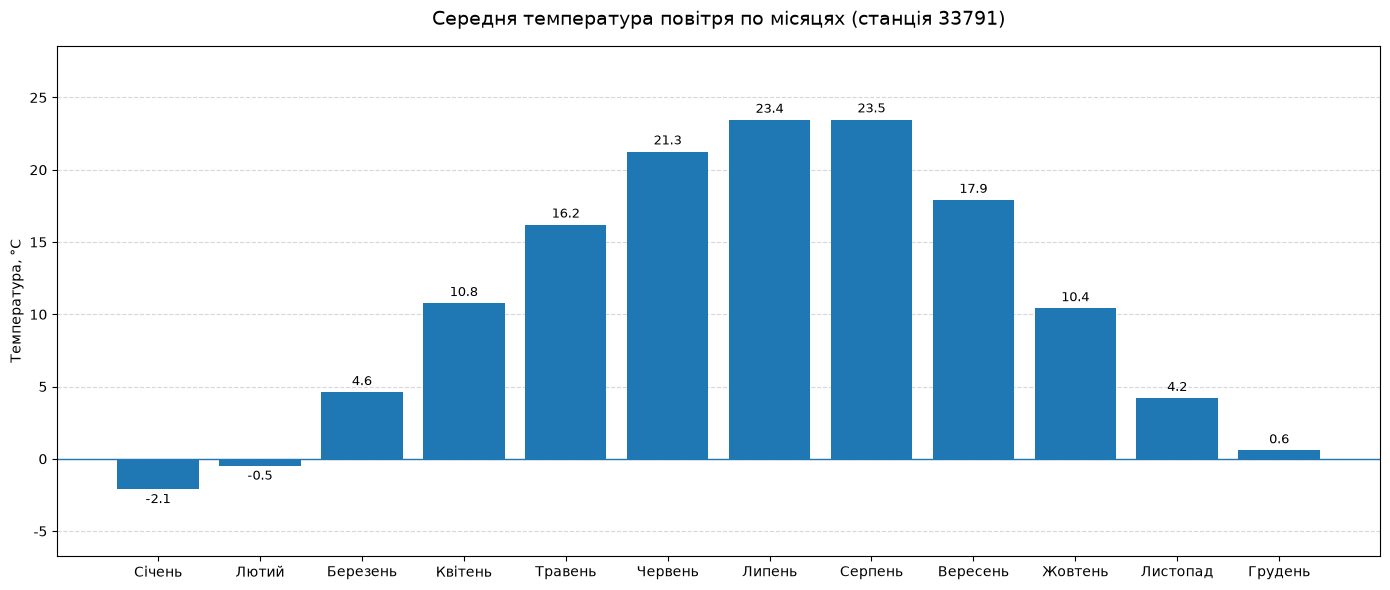

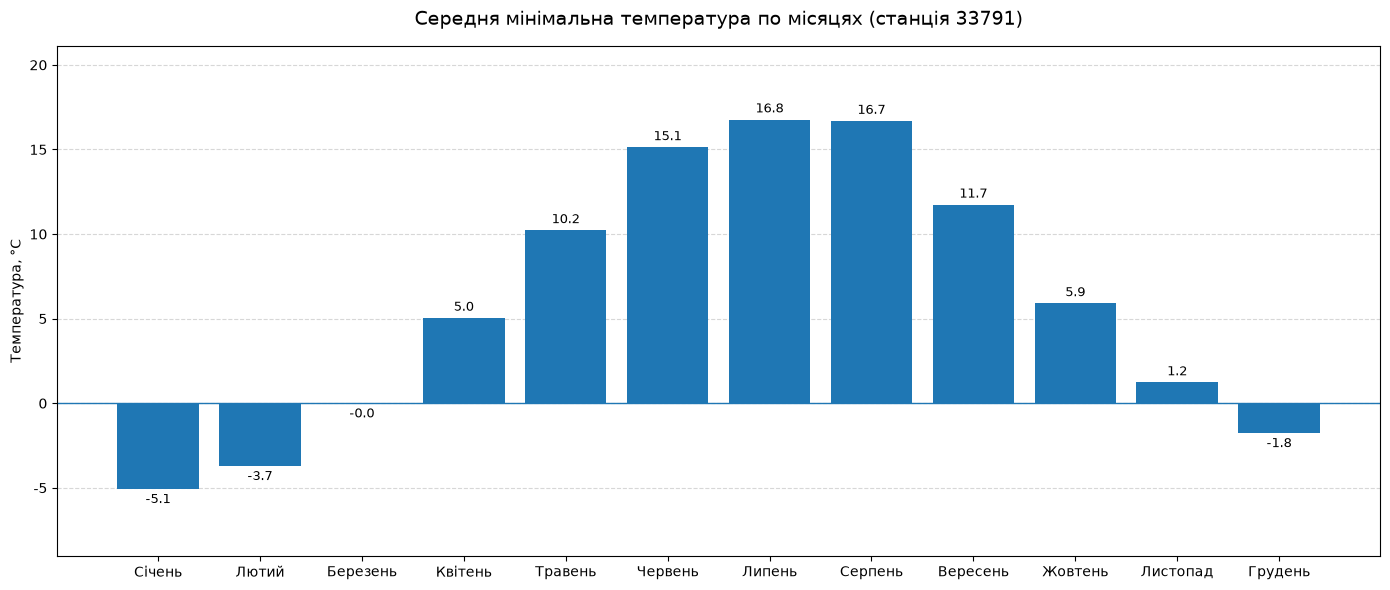

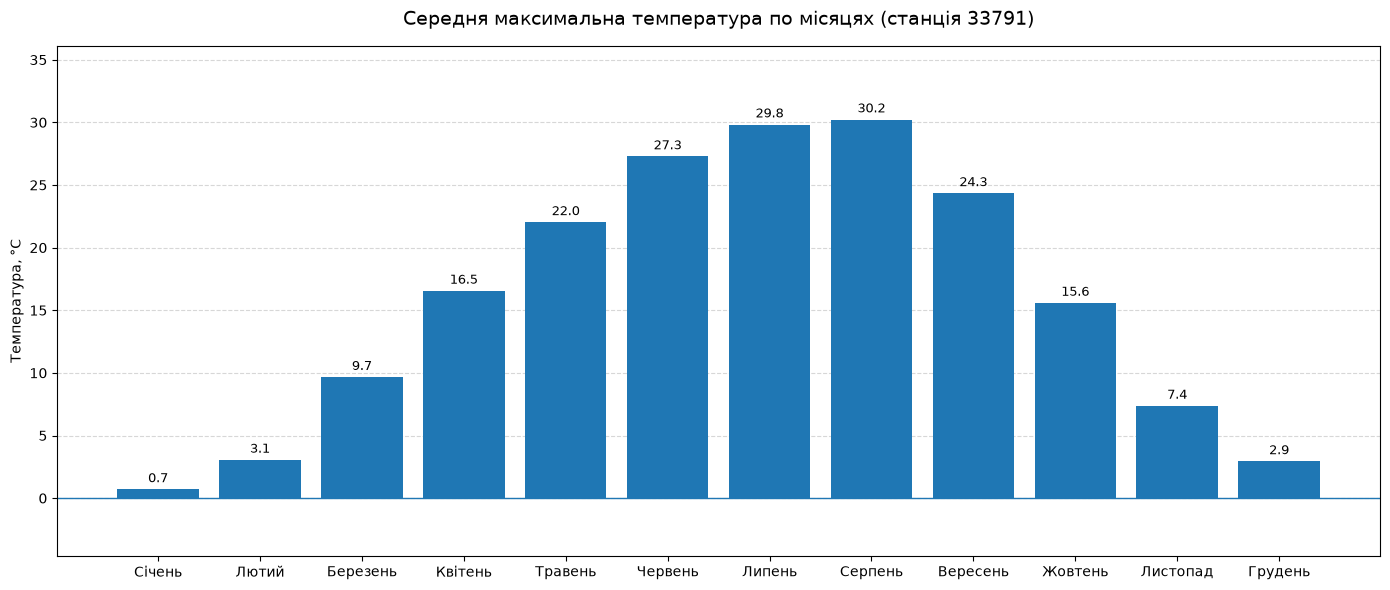

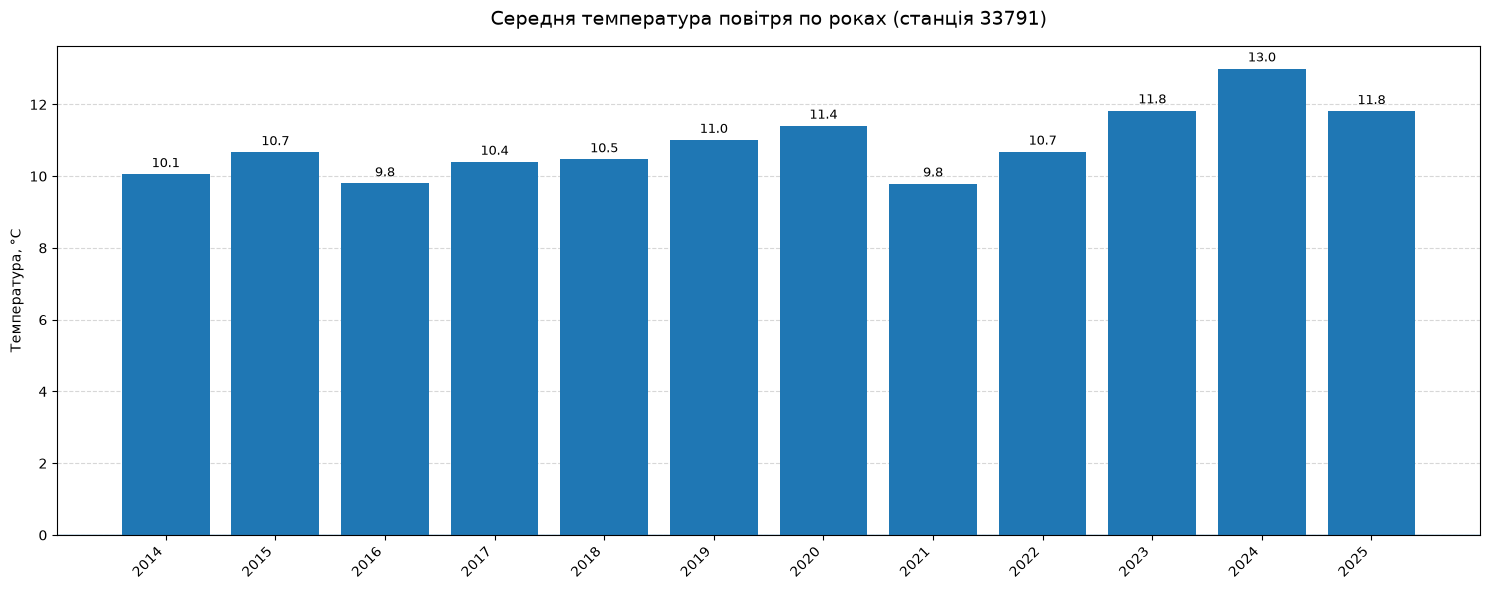

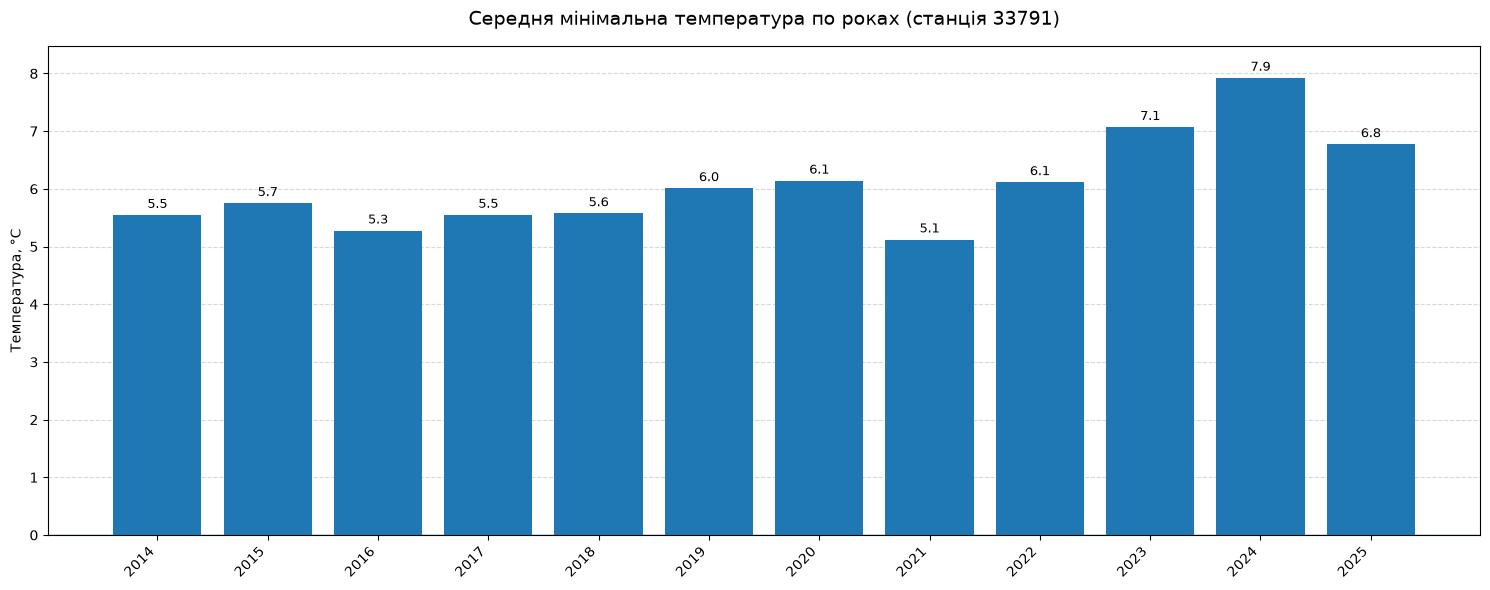

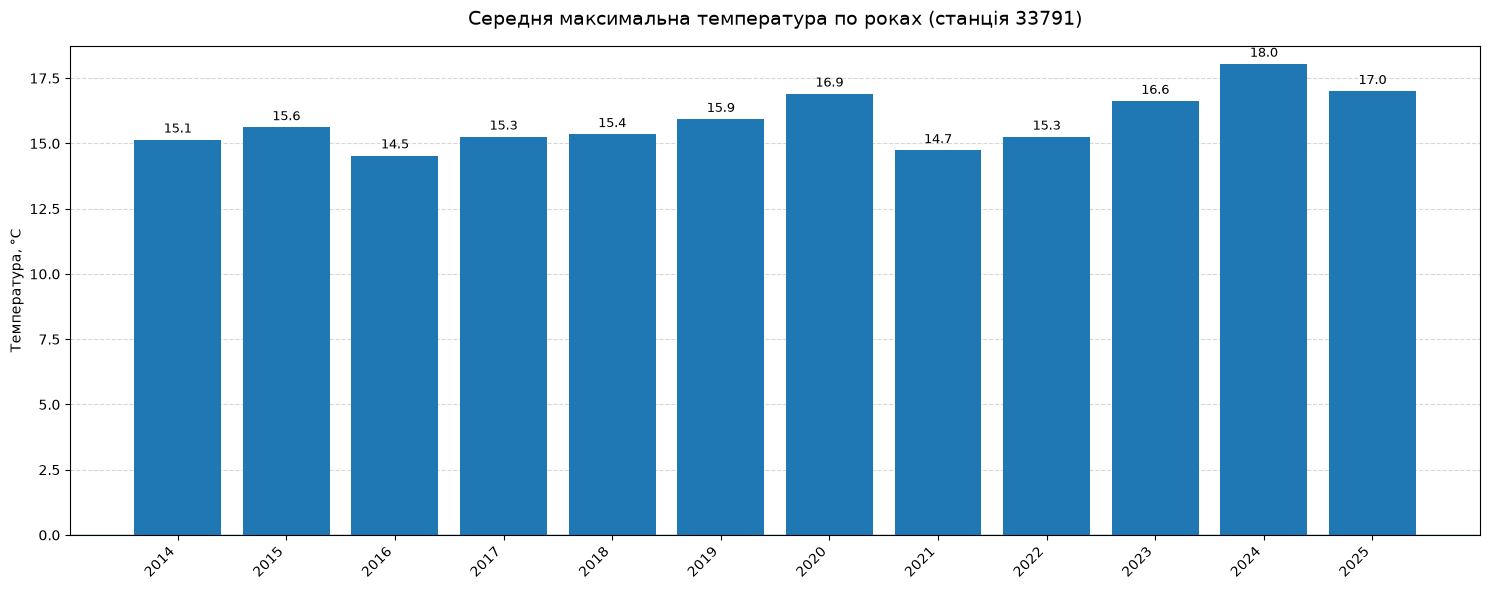


АНАЛІЗ УСПІШНО ЗАВЕРШЕНО

Створені файли:
1. Добові дані CSV:
   /content/meteostat_results/weather_daily_33791_2014-01-01_2025-12-31.csv
2. Місячні дані CSV:
   /content/meteostat_results/weather_monthly_33791_2014-01-01_2025-12-31.csv
3. Річні дані CSV:
   /content/meteostat_results/weather_yearly_33791_2014-01-01_2025-12-31.csv
4. Багаторічні середні CSV:
   /content/meteostat_results/weather_climate_monthly_33791_2014-01-01_2025-12-31.csv
5. PDF-звіт:
   /content/meteostat_results/weather_report_33791_2014-01-01_2025-12-31.pdf

Розмір PDF:
0.12 МБ


In [ ]:
# ============================================================
# АГРОМЕТЕОРОЛОГІЧНИЙ АНАЛІЗ ДАНИХ METEOSTAT
# Версія для Meteostat 2.x
#
# Результати:
# 1. CSV із щоденними архівними даними
# 2. CSV із місячними показниками
# 3. CSV із річними показниками
# 4. CSV із багаторічними середніми по місяцях
# 5. Багатосторінковий PDF-звіт із таблицями та графіками
# ============================================================

# ВАЖЛИВО ДЛЯ GOOGLE COLAB:
# Перед першим запуском виконайте в ОКРЕМІЙ комірці:
#
# %pip install --upgrade meteostat pandas matplotlib
#
# Після встановлення перезапустіть середовище виконання.

import sys
from datetime import datetime
from pathlib import Path

import meteostat as ms
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages


# ============================================================
# 1. НАЛАШТУВАННЯ
# ============================================================

# ID метеостанції Meteostat
station_id = "33791"

# Назва станції або місцевості для звіту
station_name = "Кривий Ріг / район Новомалинівки"

# Період аналізу
start = datetime(2014, 1, 1)
end = datetime(2025, 12, 31)

# Папка для результатів
output_dir = Path("meteostat_results")
output_dir.mkdir(parents=True, exist_ok=True)

# Чи показувати графіки на екрані
# False зручніше для автоматичного формування PDF
show_charts = True

# Мінімальна кількість днів із даними,
# за якої місяць вважається придатним для аналізу
minimum_days_in_month = 20

# Мінімальна кількість днів із даними,
# за якої рік вважається придатним для аналізу
minimum_days_in_year = 300

# Формат графіків
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False


# ============================================================
# 2. НАЗВИ МІСЯЦІВ
# ============================================================

uk_months = {
    1: "Січень",
    2: "Лютий",
    3: "Березень",
    4: "Квітень",
    5: "Травень",
    6: "Червень",
    7: "Липень",
    8: "Серпень",
    9: "Вересень",
    10: "Жовтень",
    11: "Листопад",
    12: "Грудень",
}


# ============================================================
# 3. НАЗВИ ФАЙЛІВ
# ============================================================

period_name = f"{start:%Y-%m-%d}_{end:%Y-%m-%d}"

raw_csv_path = output_dir / f"weather_daily_{station_id}_{period_name}.csv"
monthly_csv_path = output_dir / f"weather_monthly_{station_id}_{period_name}.csv"
yearly_csv_path = output_dir / f"weather_yearly_{station_id}_{period_name}.csv"
climate_csv_path = output_dir / f"weather_climate_monthly_{station_id}_{period_name}.csv"
pdf_path = output_dir / f"weather_report_{station_id}_{period_name}.pdf"


# ============================================================
# 4. СЛУЖБОВА ІНФОРМАЦІЯ
# ============================================================

print("=" * 70)
print("АГРОМЕТЕОРОЛОГІЧНИЙ АНАЛІЗ METEOSTAT")
print("=" * 70)
print(f"Python: {sys.version.split()[0]}")
print(f"Meteostat: {getattr(ms, '__version__', 'версія не визначена')}")
print(f"Pandas: {pd.__version__}")
print(f"Станція: {station_id} — {station_name}")
print(f"Період: {start:%d.%m.%Y} – {end:%d.%m.%Y}")
print("=" * 70)


# ============================================================
# 5. ЗАВАНТАЖЕННЯ ДАНИХ
# ============================================================

print("\nЗавантаження даних Meteostat...")

try:
    data = ms.daily(
        station_id,
        start=start,
        end=end,
    ).fetch()
except Exception as error:
    raise RuntimeError(
        "Не вдалося завантажити дані Meteostat.\n"
        f"Тип помилки: {type(error).__name__}\n"
        f"Текст помилки: {error}"
    ) from error


# ============================================================
# 6. ПЕРЕВІРКА ОТРИМАНИХ ДАНИХ
# ============================================================

if data is None or data.empty:
    raise ValueError(
        f"Meteostat не повернув даних для станції {station_id} "
        f"за період {start:%d.%m.%Y} – {end:%d.%m.%Y}."
    )

data.index = pd.to_datetime(data.index)
data.index.name = "date"
data = data.sort_index()

print(f"Отримано рядків: {len(data):,}".replace(",", " "))
print(
    "Фактичний діапазон: "
    f"{data.index.min():%d.%m.%Y} – {data.index.max():%d.%m.%Y}"
)
print("\nДоступні стовпці:")
print(data.columns.tolist())

# У Meteostat 2.x середня добова температура має назву "temp".
# Для сумісності з рештою коду створюємо стандартну колонку "tavg".
if "tavg" not in data.columns and "temp" in data.columns:
    data["tavg"] = data["temp"]
    print('\nКолонку "temp" використано як "tavg" для сумісності аналізу.')


# ============================================================
# 7. ПЕРЕВІРКА ОСНОВНИХ СТОВПЦІВ
# ============================================================

recommended_columns = ["prcp", "tavg", "tmin", "tmax"]

missing_columns = [
    column for column in recommended_columns
    if column not in data.columns
]

if missing_columns:
    print(
        "\nУВАГА: у наборі даних відсутні рекомендовані стовпці:",
        ", ".join(missing_columns),
    )


# ============================================================
# 8. ЕКСПОРТ СИРИХ ДОБОВИХ ДАНИХ
# ============================================================

data.to_csv(
    raw_csv_path,
    encoding="utf-8-sig",
    decimal=".",
)

print(f"\nЩоденні дані збережено:\n{raw_csv_path.resolve()}")


# ============================================================
# 9. ПІДГОТОВКА ДАНИХ
# ============================================================

analysis_data = data.copy()

analysis_data["year"] = analysis_data.index.year
analysis_data["month"] = analysis_data.index.month
analysis_data["month_name"] = analysis_data["month"].map(uk_months)
analysis_data["year_month"] = analysis_data.index.to_period("M").astype(str)


# ============================================================
# 10. МІСЯЧНІ АГРЕГАЦІЇ
# ============================================================

monthly_aggregation = {}

if "prcp" in analysis_data.columns:
    monthly_aggregation["prcp_sum_mm"] = ("prcp", "sum")
    monthly_aggregation["prcp_days"] = ("prcp", "count")

if "tavg" in analysis_data.columns:
    monthly_aggregation["tavg_mean_c"] = ("tavg", "mean")
    monthly_aggregation["tavg_days"] = ("tavg", "count")

if "tmin" in analysis_data.columns:
    monthly_aggregation["tmin_mean_c"] = ("tmin", "mean")
    monthly_aggregation["absolute_tmin_c"] = ("tmin", "min")

if "tmax" in analysis_data.columns:
    monthly_aggregation["tmax_mean_c"] = ("tmax", "mean")
    monthly_aggregation["absolute_tmax_c"] = ("tmax", "max")

if "wspd" in analysis_data.columns:
    monthly_aggregation["wspd_mean_kmh"] = ("wspd", "mean")

if "wpgt" in analysis_data.columns:
    monthly_aggregation["wpgt_max_kmh"] = ("wpgt", "max")

if "pres" in analysis_data.columns:
    monthly_aggregation["pres_mean_hpa"] = ("pres", "mean")

if "tsun" in analysis_data.columns:
    monthly_aggregation["tsun_sum_min"] = ("tsun", "sum")

if not monthly_aggregation:
    raise ValueError(
        "Неможливо сформувати місячні показники: "
        "не знайдено жодного придатного погодного стовпця."
    )

monthly_summary = (
    analysis_data
    .groupby(["year", "month", "month_name"], observed=False)
    .agg(**monthly_aggregation)
    .reset_index()
    .sort_values(["year", "month"])
)

monthly_summary["calendar_days"] = pd.to_datetime(
    monthly_summary["year"].astype(str)
    + "-"
    + monthly_summary["month"].astype(str)
    + "-01"
).dt.days_in_month

if "prcp_days" in monthly_summary.columns:
    monthly_summary["available_days"] = monthly_summary["prcp_days"]
elif "tavg_days" in monthly_summary.columns:
    monthly_summary["available_days"] = monthly_summary["tavg_days"]
else:
    monthly_summary["available_days"] = pd.NA

monthly_summary["month_completeness_pct"] = (
    monthly_summary["available_days"]
    / monthly_summary["calendar_days"]
    * 100
).round(1)

monthly_summary["month_is_complete"] = (
    monthly_summary["available_days"] >= minimum_days_in_month
)


# ============================================================
# 11. РІЧНІ АГРЕГАЦІЇ
# ============================================================

yearly_aggregation = {}

if "prcp" in analysis_data.columns:
    yearly_aggregation["prcp_sum_mm"] = ("prcp", "sum")
    yearly_aggregation["prcp_days"] = ("prcp", "count")

if "tavg" in analysis_data.columns:
    yearly_aggregation["tavg_mean_c"] = ("tavg", "mean")
    yearly_aggregation["tavg_days"] = ("tavg", "count")

if "tmin" in analysis_data.columns:
    yearly_aggregation["tmin_mean_c"] = ("tmin", "mean")
    yearly_aggregation["absolute_tmin_c"] = ("tmin", "min")

if "tmax" in analysis_data.columns:
    yearly_aggregation["tmax_mean_c"] = ("tmax", "mean")
    yearly_aggregation["absolute_tmax_c"] = ("tmax", "max")

if "wspd" in analysis_data.columns:
    yearly_aggregation["wspd_mean_kmh"] = ("wspd", "mean")

if "wpgt" in analysis_data.columns:
    yearly_aggregation["wpgt_max_kmh"] = ("wpgt", "max")

if "pres" in analysis_data.columns:
    yearly_aggregation["pres_mean_hpa"] = ("pres", "mean")

if "tsun" in analysis_data.columns:
    yearly_aggregation["tsun_sum_min"] = ("tsun", "sum")

yearly_summary = (
    analysis_data
    .groupby("year")
    .agg(**yearly_aggregation)
    .reset_index()
    .sort_values("year")
)

if "prcp_days" in yearly_summary.columns:
    yearly_summary["available_days"] = yearly_summary["prcp_days"]
elif "tavg_days" in yearly_summary.columns:
    yearly_summary["available_days"] = yearly_summary["tavg_days"]
else:
    yearly_summary["available_days"] = pd.NA

yearly_summary["year_is_complete"] = (
    yearly_summary["available_days"] >= minimum_days_in_year
)


# ============================================================
# 12. БАГАТОРІЧНІ СЕРЕДНІ ПО МІСЯЦЯХ
# ============================================================

climate_rows = []

for month_number in range(1, 13):
    month_data = analysis_data[analysis_data["month"] == month_number]

    row = {
        "month": month_number,
        "month_name": uk_months[month_number],
    }

    if "prcp" in analysis_data.columns:
        monthly_prcp_years = (
            month_data
            .groupby("year")["prcp"]
            .sum(min_count=1)
        )
        row["prcp_mean_monthly_sum_mm"] = monthly_prcp_years.mean()
        row["prcp_median_monthly_sum_mm"] = monthly_prcp_years.median()

    if "tavg" in analysis_data.columns:
        row["tavg_mean_c"] = month_data["tavg"].mean()

    if "tmin" in analysis_data.columns:
        row["tmin_mean_c"] = month_data["tmin"].mean()
        row["absolute_tmin_c"] = month_data["tmin"].min()

    if "tmax" in analysis_data.columns:
        row["tmax_mean_c"] = month_data["tmax"].mean()
        row["absolute_tmax_c"] = month_data["tmax"].max()

    climate_rows.append(row)

climate_monthly = pd.DataFrame(climate_rows)


# ============================================================
# 13. ЕКСПОРТ АГРЕГОВАНИХ ТАБЛИЦЬ
# ============================================================

monthly_summary.to_csv(
    monthly_csv_path,
    index=False,
    encoding="utf-8-sig",
)

yearly_summary.to_csv(
    yearly_csv_path,
    index=False,
    encoding="utf-8-sig",
)

climate_monthly.to_csv(
    climate_csv_path,
    index=False,
    encoding="utf-8-sig",
)

print(f"Місячні результати збережено:\n{monthly_csv_path.resolve()}")
print(f"Річні результати збережено:\n{yearly_csv_path.resolve()}")
print(f"Багаторічні середні збережено:\n{climate_csv_path.resolve()}")


# ============================================================
# 14. ДОПОМІЖНІ ФУНКЦІЇ
# ============================================================

def clean_series(series: pd.Series) -> pd.Series:
    """Перетворює значення на числа та видаляє пропуски."""
    result = pd.to_numeric(series, errors="coerce")
    return result.dropna()


def draw_bar_chart(
    series: pd.Series,
    title: str,
    ylabel: str,
    pdf: PdfPages,
    x_labels=None,
    value_format: str = "%.1f",
    figsize=(14, 6),
    rotation: int = 0,
    zero_line: bool = False,
) -> None:
    """Створює стовпчиковий графік і додає його до PDF."""

    series = clean_series(series)

    if series.empty:
        print(f"Пропущено графік: {title} — немає даних.")
        return

    if x_labels is None:
        labels = [str(value) for value in series.index]
    else:
        labels = list(x_labels)

    if len(labels) != len(series):
        raise ValueError(
            f"Кількість підписів X ({len(labels)}) "
            f"не відповідає кількості значень ({len(series)})."
        )

    fig, ax = plt.subplots(figsize=figsize)

    bars = ax.bar(
        range(len(series)),
        series.values,
    )

    ax.set_xticks(range(len(series)))
    ax.set_xticklabels(
        labels,
        rotation=rotation,
        ha="right" if rotation else "center",
    )

    ax.bar_label(
        bars,
        fmt=value_format,
        padding=3,
        fontsize=9,
    )

    ax.set_title(title, fontsize=14, pad=15)
    ax.set_ylabel(ylabel)

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.5,
    )
    ax.set_axisbelow(True)

    if zero_line:
        ax.axhline(y=0, linewidth=1)

    values = series.values.astype(float)
    data_min = values.min()
    data_max = values.max()
    data_range = data_max - data_min

    if data_range == 0:
        data_range = abs(data_max) if data_max != 0 else 1

    upper_limit = data_max + data_range * 0.20
    lower_limit = min(0, data_min - data_range * 0.18)

    ax.set_ylim(lower_limit, upper_limit)

    fig.tight_layout()
    pdf.savefig(fig, bbox_inches="tight")

    if show_charts:
        plt.show()

    plt.close(fig)


def add_title_page(pdf: PdfPages) -> None:
    """Створює титульну сторінку PDF-звіту."""

    fig = plt.figure(figsize=(11.69, 8.27))
    plt.axis("off")

    title_text = (
        "АГРОМЕТЕОРОЛОГІЧНИЙ ЗВІТ\n\n"
        f"Метеостанція: {station_name}\n"
        f"ID Meteostat: {station_id}\n"
        f"Період: {start:%d.%m.%Y} – {end:%d.%m.%Y}\n\n"
        f"Фактичний початок даних: {data.index.min():%d.%m.%Y}\n"
        f"Фактичний кінець даних: {data.index.max():%d.%m.%Y}\n"
        f"Кількість добових записів: {len(data)}\n\n"
        "Звіт містить:\n"
        "• місячні та річні суми опадів;\n"
        "• середні, мінімальні та максимальні температури;\n"
        "• оцінку повноти архівних даних;\n"
        "• багаторічні середні показники;\n"
        "• графічний аналіз погодних умов."
    )

    plt.text(
        0.5,
        0.56,
        title_text,
        ha="center",
        va="center",
        fontsize=16,
        linespacing=1.5,
    )

    plt.text(
        0.5,
        0.08,
        f"Дата створення звіту: {datetime.now():%d.%m.%Y %H:%M}",
        ha="center",
        va="center",
        fontsize=10,
    )

    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)


def add_dataframe_page(
    pdf: PdfPages,
    dataframe: pd.DataFrame,
    title: str,
    max_rows: int = 25,
    font_size: int = 7,
) -> None:
    """Додає DataFrame до PDF, розбиваючи довгу таблицю на сторінки."""

    if dataframe.empty:
        return

    display_df = dataframe.copy()

    numeric_columns = display_df.select_dtypes(
        include="number",
    ).columns

    display_df[numeric_columns] = (
        display_df[numeric_columns].round(1)
    )

    # Pandas 3.x не дозволяє вставляти текст у nullable Float64/Int64.
    # Перед заміною пропусків перетворюємо таблицю на object.
    display_df = display_df.astype(object).where(
        pd.notna(display_df),
        "—"
    )

    for start_row in range(0, len(display_df), max_rows):
        end_row = start_row + max_rows
        page_df = display_df.iloc[start_row:end_row]

        fig, ax = plt.subplots(figsize=(16, 9))
        ax.axis("off")

        page_number = start_row // max_rows + 1
        total_pages = (len(display_df) + max_rows - 1) // max_rows

        ax.set_title(
            f"{title} — сторінка {page_number}/{total_pages}",
            fontsize=14,
            pad=20,
        )

        table = ax.table(
            cellText=page_df.values,
            colLabels=page_df.columns,
            loc="center",
            cellLoc="center",
        )

        table.auto_set_font_size(False)
        table.set_fontsize(font_size)
        table.scale(1, 1.35)

        try:
            table.auto_set_column_width(
                col=list(range(len(page_df.columns)))
            )
        except AttributeError:
            pass

        fig.tight_layout()
        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)


# ============================================================
# 15. ПІДГОТОВКА SERIES ДЛЯ ГРАФІКІВ
# ============================================================

yearly_indexed = yearly_summary.set_index("year")
climate_indexed = climate_monthly.set_index("month")

year_prcp = (
    yearly_indexed["prcp_sum_mm"]
    if "prcp_sum_mm" in yearly_indexed.columns
    else pd.Series(dtype=float)
)

year_tmean = (
    yearly_indexed["tavg_mean_c"]
    if "tavg_mean_c" in yearly_indexed.columns
    else pd.Series(dtype=float)
)

year_tmin = (
    yearly_indexed["tmin_mean_c"]
    if "tmin_mean_c" in yearly_indexed.columns
    else pd.Series(dtype=float)
)

year_tmax = (
    yearly_indexed["tmax_mean_c"]
    if "tmax_mean_c" in yearly_indexed.columns
    else pd.Series(dtype=float)
)

monthly_prcp = (
    climate_indexed["prcp_mean_monthly_sum_mm"]
    if "prcp_mean_monthly_sum_mm" in climate_indexed.columns
    else pd.Series(dtype=float)
)

monthly_tavg = (
    climate_indexed["tavg_mean_c"]
    if "tavg_mean_c" in climate_indexed.columns
    else pd.Series(dtype=float)
)

monthly_tmin = (
    climate_indexed["tmin_mean_c"]
    if "tmin_mean_c" in climate_indexed.columns
    else pd.Series(dtype=float)
)

monthly_tmax = (
    climate_indexed["tmax_mean_c"]
    if "tmax_mean_c" in climate_indexed.columns
    else pd.Series(dtype=float)
)


# ============================================================
# 16. ФОРМУВАННЯ PDF-ЗВІТУ
# ============================================================

print("\nФормування PDF-звіту...")

try:
    with PdfPages(pdf_path) as pdf:

        pdf_metadata = pdf.infodict()
        pdf_metadata["Title"] = (
            f"Агрометеорологічний звіт — станція {station_id}"
        )
        pdf_metadata["Author"] = "Python / Meteostat"
        pdf_metadata["Subject"] = (
            "Аналіз архівних погодних даних для агрономічних цілей"
        )
        pdf_metadata["Keywords"] = (
            "Meteostat, опади, температура, агрометеорологія"
        )
        pdf_metadata["CreationDate"] = datetime.now()

        add_title_page(pdf)

        add_dataframe_page(
            pdf=pdf,
            dataframe=yearly_summary,
            title="Річні погодні показники",
            max_rows=22,
            font_size=7,
        )

        add_dataframe_page(
            pdf=pdf,
            dataframe=climate_monthly,
            title="Багаторічні середні показники по місяцях",
            max_rows=15,
            font_size=8,
        )

        add_dataframe_page(
            pdf=pdf,
            dataframe=monthly_summary,
            title="Місячні погодні показники",
            max_rows=24,
            font_size=6,
        )

        if not monthly_prcp.empty:
            month_labels = [
                uk_months[int(month)]
                for month in monthly_prcp.index
            ]

            draw_bar_chart(
                series=monthly_prcp,
                title=(
                    "Середня багаторічна сума опадів по місяцях "
                    f"(станція {station_id})"
                ),
                ylabel="Опади, мм",
                pdf=pdf,
                x_labels=month_labels,
                value_format="%.1f",
                figsize=(14, 6),
            )

        if not year_prcp.empty:
            draw_bar_chart(
                series=year_prcp,
                title=(
                    "Сумарна кількість опадів по роках "
                    f"(станція {station_id})"
                ),
                ylabel="Опади, мм",
                pdf=pdf,
                value_format="%.1f",
                figsize=(15, 6),
                rotation=45,
            )

        if not monthly_tavg.empty:
            month_labels = [
                uk_months[int(month)]
                for month in monthly_tavg.index
            ]

            draw_bar_chart(
                series=monthly_tavg,
                title=(
                    "Середня температура повітря по місяцях "
                    f"(станція {station_id})"
                ),
                ylabel="Температура, °C",
                pdf=pdf,
                x_labels=month_labels,
                value_format="%.1f",
                figsize=(14, 6),
                zero_line=True,
            )

        if not monthly_tmin.empty:
            month_labels = [
                uk_months[int(month)]
                for month in monthly_tmin.index
            ]

            draw_bar_chart(
                series=monthly_tmin,
                title=(
                    "Середня мінімальна температура по місяцях "
                    f"(станція {station_id})"
                ),
                ylabel="Температура, °C",
                pdf=pdf,
                x_labels=month_labels,
                value_format="%.1f",
                figsize=(14, 6),
                zero_line=True,
            )

        if not monthly_tmax.empty:
            month_labels = [
                uk_months[int(month)]
                for month in monthly_tmax.index
            ]

            draw_bar_chart(
                series=monthly_tmax,
                title=(
                    "Середня максимальна температура по місяцях "
                    f"(станція {station_id})"
                ),
                ylabel="Температура, °C",
                pdf=pdf,
                x_labels=month_labels,
                value_format="%.1f",
                figsize=(14, 6),
                zero_line=True,
            )

        if not year_tmean.empty:
            draw_bar_chart(
                series=year_tmean,
                title=(
                    "Середня температура повітря по роках "
                    f"(станція {station_id})"
                ),
                ylabel="Температура, °C",
                pdf=pdf,
                value_format="%.1f",
                figsize=(15, 6),
                rotation=45,
                zero_line=True,
            )

        if not year_tmin.empty:
            draw_bar_chart(
                series=year_tmin,
                title=(
                    "Середня мінімальна температура по роках "
                    f"(станція {station_id})"
                ),
                ylabel="Температура, °C",
                pdf=pdf,
                value_format="%.1f",
                figsize=(15, 6),
                rotation=45,
                zero_line=True,
            )

        if not year_tmax.empty:
            draw_bar_chart(
                series=year_tmax,
                title=(
                    "Середня максимальна температура по роках "
                    f"(станція {station_id})"
                ),
                ylabel="Температура, °C",
                pdf=pdf,
                value_format="%.1f",
                figsize=(15, 6),
                rotation=45,
                zero_line=True,
            )

except Exception as error:
    raise RuntimeError(
        "Помилка під час формування PDF-звіту.\n"
        f"Тип помилки: {type(error).__name__}\n"
        f"Текст помилки: {error}"
    ) from error


# ============================================================
# 17. ПІДСУМКОВЕ ПОВІДОМЛЕННЯ
# ============================================================

print("\n" + "=" * 70)
print("АНАЛІЗ УСПІШНО ЗАВЕРШЕНО")
print("=" * 70)

print("\nСтворені файли:")
print(f"1. Добові дані CSV:\n   {raw_csv_path.resolve()}")
print(f"2. Місячні дані CSV:\n   {monthly_csv_path.resolve()}")
print(f"3. Річні дані CSV:\n   {yearly_csv_path.resolve()}")
print(f"4. Багаторічні середні CSV:\n   {climate_csv_path.resolve()}")
print(f"5. PDF-звіт:\n   {pdf_path.resolve()}")

print("\nРозмір PDF:")
print(f"{pdf_path.stat().st_size / 1024 / 1024:.2f} МБ")